### Thư viện cần thiết

In [1]:
import math
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

from cords.utils.models.linear_regression import LogisticNet
from cords.utils.data.datasets.SL import gen_dataset
from cords.selectionstrategies.SL.fixedweightstrategy import FixedWeightStrategy
from cords.selectionstrategies.helpers.omp_solvers import OrthogonalMP, OrthogonalMP_REG, OrthogonalMP_REG_Parallel

c:\Users\phanb\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Xử lý dữ liệu 

Nhập dữ liệu

In [2]:
data = pd.read_csv('D:\\Code\\Python\\Jupyter Notebook\\HeartDisease\\2022\\heart_2022_no_nans.csv')
display(data.head())
display(data.shape)
display(data.info())

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.60,71.67,27.99,No,No,Yes,Yes,"Yes, received Tdap",No,No
1,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,None of them,No,...,1.78,95.25,30.13,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
2,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,...,1.85,108.86,31.66,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
3,Alabama,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.70,90.72,31.32,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
4,Alabama,Female,Good,3.0,15.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,...,1.55,79.38,33.07,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


(246022, 40)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246022 entries, 0 to 246021
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      246022 non-null  object 
 1   Sex                        246022 non-null  object 
 2   GeneralHealth              246022 non-null  object 
 3   PhysicalHealthDays         246022 non-null  float64
 4   MentalHealthDays           246022 non-null  float64
 5   LastCheckupTime            246022 non-null  object 
 6   PhysicalActivities         246022 non-null  object 
 7   SleepHours                 246022 non-null  float64
 8   RemovedTeeth               246022 non-null  object 
 9   HadHeartAttack             246022 non-null  object 
 10  HadAngina                  246022 non-null  object 
 11  HadStroke                  246022 non-null  object 
 12  HadAsthma                  246022 non-null  object 
 13  HadSkinCancer              24

None

Loại bỏ các cột không cần thiết, bị trùng

In [3]:
colsDrop = ['State', 'RemovedTeeth', 'HadSkinCancer', 'HadArthritis', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 
            'DifficultyConcentrating', 'HIVTesting', 'TetanusLast10Tdap']
data = data.drop(colsDrop, axis=1)
data.drop_duplicates()

display(data.shape)

(246022, 31)

Chia dữ liệu thành tập phân biệt

In [4]:
# Chuyển đổi các giá trị trong cột 'HadHeartAttack' từ 'Yes'/'No' sang 1/0
data['HadHeartAttack'] = data['HadHeartAttack'].replace({'Yes': 1, 'No': 0})
# Tách dữ liệu thành các biến độc lập (X) và biến mục tiêu (y)
X = data.drop('HadHeartAttack', axis=1)
y = data['HadHeartAttack']

# Chia thành tập huấn luyện và tập kiểm tra 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

categoricalCols = X_train.select_dtypes(include=['object']).columns.tolist()
numericalCols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Chuyển dữ liệu chữ thành số
encodeDict = {}
for col in categoricalCols:
    encoder = LabelEncoder()
    X_train[col] = encoder.fit_transform(X_train[col])
    X_test[col] = encoder.transform(X_test[col])
    encodeDict[col] = encoder

# Chuẩn hóa dữ liệu số    
scaler = StandardScaler()
X_train[numericalCols] = scaler.fit_transform(X_train[numericalCols])
X_test[numericalCols] = scaler.transform(X_test[numericalCols])

C:\Users\phanb\AppData\Local\Temp\ipykernel_3112\2383305543.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['HadHeartAttack'] = data['HadHeartAttack'].replace({'Yes': 1, 'No': 0})


### Tạo coreset

In [5]:
def compute_gradients_per_sample(X: torch.Tensor, y: torch.Tensor, model, device='cpu', batch_size: int = 32):
    # Chuyển X, y thành DataLoader tạm
    dataset = torch.utils.data.TensorDataset(X, y)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)

    # Loss per-sample
    loss_fn = nn.MSELoss(reduction='none')

    # Lấy kích thước embedding nếu có layer cuối
    embDim = model.get_embedding_dim() #if getattr('linear_layer', False) else None

    grads_list = []
    l1_list = [] #if getattr('linear_layer', False) else None

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        out, l1 = model(inputs, last=True)
        losses = loss_fn(out, targets)           # shape (B,)
        grad_out = torch.autograd.grad(losses.sum(), out)[0]  # shape (B, num_classes)
        
        if grad_out.dim() == 1:
            grad_out = grad_out.unsqueeze(1)  # Đảm bảo grad_out có shape (B, num_classes)

        grads_list.append(grad_out.detach().cpu())

        # if getattr('linear_layer', False):
        grad_out_exp = grad_out.repeat_interleave(embDim, dim=1)
       
        grad_l1 = grad_out_exp * l1
        l1_list.append(grad_l1.detach().cpu())

    # Ghép lại
    grads = torch.cat(grads_list, dim=0)  # (N_train, num_classes)
    # if getattr('linear_layer', False):
    l1_grads = torch.cat(l1_list, dim=0)  # (N_train, num_classes * embDim)
    grads = torch.cat((grads, l1_grads), dim=1)  # (N_train, total_grad_dim)

    return grads
    
def genCoresets(X_train, y_train):
    model = LogisticNet(input_dim=X_train.shape[1])
    model.to('cpu')

    grad_per_ele = compute_gradients_per_sample(
        X=torch.tensor(X_train, dtype=torch.float32),
        y=torch.tensor(y_train, dtype=torch.float32),
        model=model,
        device='cpu',
        batch_size=32
    )
    
    grad_per_ele = grad_per_ele.numpy()  # Chuyển về numpy để sử dụng OrthogonalMP_REG
    sum_val_grad = grad_per_ele.sum(axis=1)

    x = OrthogonalMP_REG(grad_per_ele, sum_val_grad, positive=True)
    coreset_idx = np.nonzero(x)[0]

    X_coreset = X_train[coreset_idx]
    y_coreset = y_train[coreset_idx]
    weights_coreset = x[coreset_idx]

    return X_coreset, y_coreset, weights_coreset


### Huấn luyện

Trên toàn bộ tập dữ liệu

Logistic Regression Performance(all):
Accuracy: 0.94751
ROC AUC: 0.88324
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     69776
           1       0.54      0.24      0.33      4031

    accuracy                           0.95     73807
   macro avg       0.75      0.61      0.65     73807
weighted avg       0.93      0.95      0.94     73807



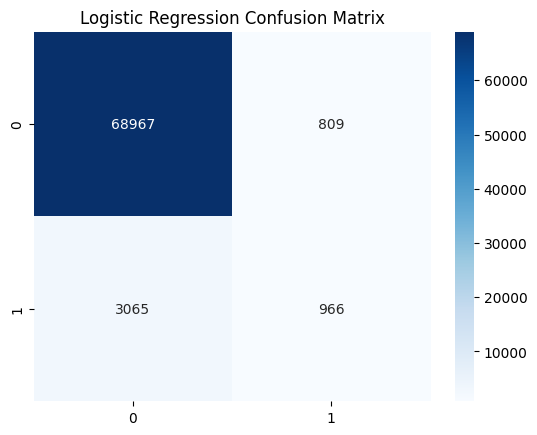

In [6]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

print("Logistic Regression Performance(all):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.5f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.5f}")
print(classification_report(y_test, y_pred))
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Trên coreset

c:\Users\phanb\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\phanb\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Logistic Regression Performance(coreset):
Accuracy: 0.94494
ROC AUC: 0.73654
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     69776
           1       0.20      0.00      0.01      4031

    accuracy                           0.94     73807
   macro avg       0.57      0.50      0.49     73807
weighted avg       0.90      0.94      0.92     73807



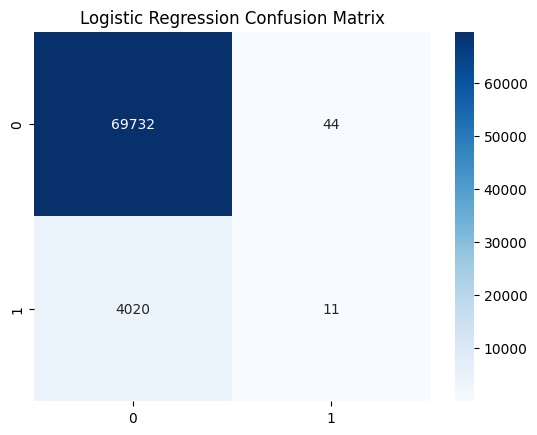

In [7]:
X_coreset, y_coreset, weights_coreset = genCoresets(X_train.values, y_train.values)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_coreset, y_coreset, sample_weight=weights_coreset)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

print("Logistic Regression Performance(coreset):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.5f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.5f}")
print(classification_report(y_test, y_pred))
plt.title("Logistic Regression Confusion Matrix")
plt.show()